1. Data Import, Visualization and Preparation (10 points)

    • Preprocess the data and visualize some images with the corresponding labels to be sure everything is working
    
    • Split the dataset into training (70%), validation (15%), and test (15%) sets

In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
from torchvision import datasets, transforms, utils
import torchvision
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import PIL
import PIL.Image
from torch.utils.data import DataLoader, random_split, Subset

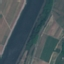

In [2]:
#first look at a picture
PIL.Image.open(fp="data/EuroSAT_RGB/River/River_1.jpg")


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# initial visualization of images
transform = transforms.Compose([
    transforms.ToTensor() 
])

#load whole dataset
image_data = datasets.ImageFolder(root="data/EuroSAT_RGB/", transform=transform)

class_names = image_data.classes

#load raw dataset
raw_image_data = datasets.ImageFolder(root="data/EuroSAT_RGB/")

cuda


In [4]:
#define split ratios 70 15 15
total_size = len(image_data)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

#split dataset
train_dataset, val_dataset, test_dataset = random_split(
    image_data, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

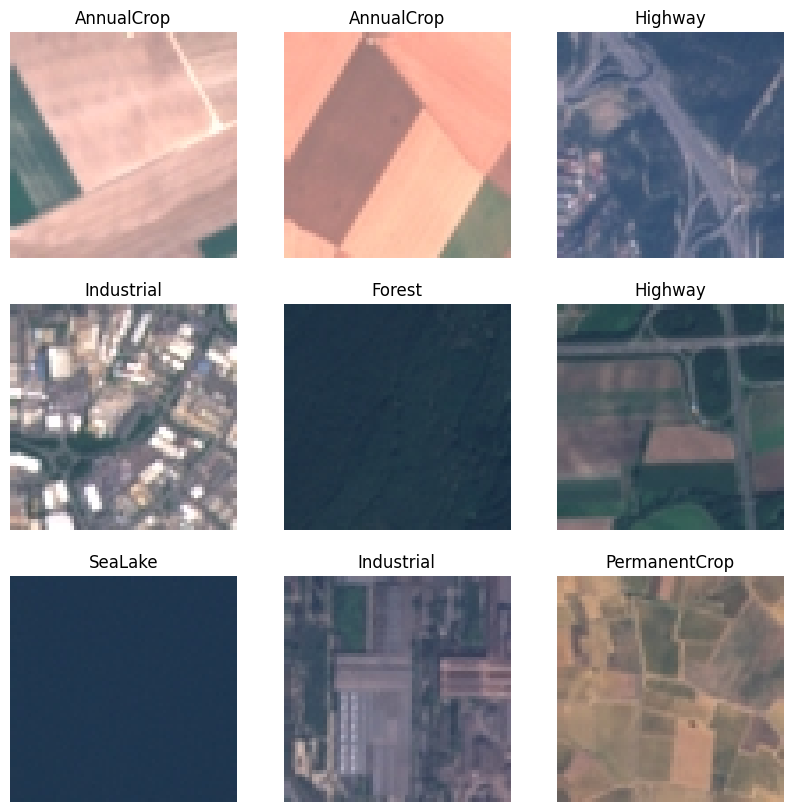

In [5]:
dataiter = iter(DataLoader(train_dataset, batch_size=9, shuffle=True))
images, labels = next(dataiter)

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

In [6]:
first_image = images[0].numpy()
print(f"Example: {np.min(first_image), np.max(first_image)}")

Example: (np.float32(0.24313726), np.float32(1.0))


2. CNN Model Building, Training and Testing (10 points)

    • Build a CNN to classify the images into the 10 land use categories

    • An accuracy above 85% is considered a good result for this dataset

    • Train and test the model using techniques for improving performance, such as:

        - Data augmentation

        - Early stopping

        - Regularization techniques (dropout, L1/L2 regularization)
        
        - Appropriate optimization algorithms

In [7]:
#define transformations for training and testing
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))  #for rgb not greyscale
])
#augment the training set but not the test or validation set
train_transform_augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, shear=10, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))  
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))  
])

In [8]:
#tranform with correct transformer and augment training data for better results
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_test_transform
test_dataset.dataset.transform = val_test_transform

batch_size = 512 #the larger the batch size desto faster, but memory needed, ideally larger batch size

#create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Create DataLoaders for training, validation, and testing for the mlp later on
train_loader_mlp = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader_mlp = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader_mlp = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [9]:
#EARLY STOPPING AND TRAINING FUCNTIONS

class EarlyStopping:
    def __init__(self, patience=25, min_delta=0.0001, path='checkpoint.pt'):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.path = path  # Path to save the best model

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            if val_loss < self.best_loss:
                self.save_checkpoint(val_loss, model)
                self.best_loss = val_loss
                self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decrease.'''
        torch.save(model.state_dict(), self.path)
        print(f'Validation loss decreased ({self.best_loss:.6f} --> {val_loss:.6f}).  Saving model ...')

def train_cnn_model(epochs, model, optimizer, criterion, train_loader, val_loader, early_stopper):
    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()

            # Get only the logits from the model's output which is the first element of the tuple
            output, _ = model(data)  # Adjust here to unpack the tuple and ignore the second output
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_losses.append(train_loss / len(train_loader))

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                # Again, get only the logits when evaluating
                output, _ = model(data)
                loss = criterion(output, target)
                val_loss += loss.item()
        val_losses.append(val_loss / len(val_loader))
        print(f'Epoch: {epoch+1}, Training Loss: {train_loss / len(train_loader):.4f}, Validation Loss: {val_loss / len(val_loader):.4f}')

        # Early stopping call and pass the model for checkpointing
        early_stopper(val_loss / len(val_loader), model)
        if early_stopper.early_stop:
            print("Early stopping triggered.")
            break

    # Load the best model weights
    model.load_state_dict(torch.load('checkpoint.pt'))
    return train_losses, val_losses


In [10]:
from torch import nn
from torchsummary import summary

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),


            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),


            nn.ReLU(),

            nn.MaxPool2d(2, 2),

            nn.Dropout(0.35),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),

            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),

            nn.ReLU(),

            nn.MaxPool2d(2, 2),

            nn.Dropout(0.35)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(64 * 16 * 16, 64),


            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.features(x)
        last_conv_output = x
        x = self.classifier(x)
        return x, last_conv_output

# Instantiate and summarize the model
cnn_model = CNN().to(device)
summary(cnn_model, input_size=(3, 64, 64))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 64, 64]             896
              ReLU-2           [-1, 32, 64, 64]               0
            Conv2d-3           [-1, 32, 64, 64]           9,248
              ReLU-4           [-1, 32, 64, 64]               0
         MaxPool2d-5           [-1, 32, 32, 32]               0
           Dropout-6           [-1, 32, 32, 32]               0
            Conv2d-7           [-1, 64, 32, 32]          18,496
              ReLU-8           [-1, 64, 32, 32]               0
            Conv2d-9           [-1, 64, 32, 32]          36,928
             ReLU-10           [-1, 64, 32, 32]               0
        MaxPool2d-11           [-1, 64, 16, 16]               0
          Dropout-12           [-1, 64, 16, 16]               0
          Flatten-13                [-1, 16384]               0
           Linear-14                   

Epoch: 1, Training Loss: 1.9009, Validation Loss: 1.4823
Validation loss decreased (1.482290 --> 1.482290).  Saving model ...
Epoch: 2, Training Loss: 1.3861, Validation Loss: 1.0654
Validation loss decreased (1.482290 --> 1.065378).  Saving model ...
Epoch: 3, Training Loss: 1.1295, Validation Loss: 0.8781
Validation loss decreased (1.065378 --> 0.878125).  Saving model ...
Epoch: 4, Training Loss: 0.9798, Validation Loss: 0.8131
Validation loss decreased (0.878125 --> 0.813104).  Saving model ...
Epoch: 5, Training Loss: 0.8818, Validation Loss: 0.6708
Validation loss decreased (0.813104 --> 0.670770).  Saving model ...
Epoch: 6, Training Loss: 0.7778, Validation Loss: 0.7033
Epoch: 7, Training Loss: 0.7737, Validation Loss: 0.6772
Epoch: 8, Training Loss: 0.6959, Validation Loss: 0.5915
Validation loss decreased (0.670770 --> 0.591524).  Saving model ...
Epoch: 9, Training Loss: 0.6588, Validation Loss: 0.5434
Validation loss decreased (0.591524 --> 0.543448).  Saving model ...
Epoc

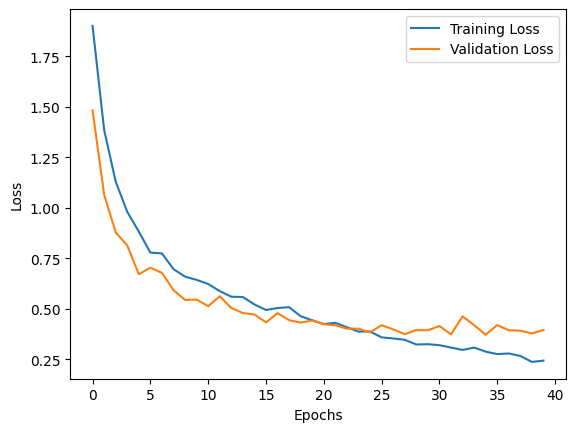

In [11]:
epochs = 50
patience = 5
lr = 0.001
reg = 0.0001


#CNN model, criterion, optimizer, and early stopping initialization
criterion = nn.CrossEntropyLoss() #multiclass classification
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=lr, weight_decay=reg)  # Ensure this is for the cnn_model
early_stopper = EarlyStopping(patience=patience)

# Training the model
train_losses, val_losses = train_cnn_model(epochs, cnn_model, cnn_optimizer, criterion, train_loader, val_loader, early_stopper)

# Plotting the training and validation losses
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [12]:
#test model on validation set
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch

# Function to evaluate the model on the validation set
def evaluate_model(data_loader, model):
    model.eval()  # Set the model to evaluation mode
    y_true = []
    y_preds = []

    # Collect all labels and model outputs
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[0]  # If the model returns a tuple, select only the logits
            _, predicted = torch.max(outputs, 1)  # Get the index of the max log-probability
            y_preds.extend(predicted.view(-1).cpu().numpy())  # Store predictions
            y_true.extend(labels.cpu().numpy())

    # Calculate accuracy
    accuracy = accuracy_score(y_true, y_preds)
    print("Accuracy:", accuracy)
    print("Classification Report:\n", classification_report(y_true, y_preds, digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_preds))

    return accuracy

# Evaluate CNN model
print("\n---------------CNN MODEL---------------\n")
cnn_accuracy = evaluate_model(val_loader, cnn_model)


---------------CNN MODEL---------------

Accuracy: 0.8831810323536676
Classification Report:
               precision    recall  f1-score   support

           0     0.9319    0.8706    0.9002       456
           1     0.9597    0.9597    0.9597       472
           2     0.8235    0.8018    0.8125       454
           3     0.7850    0.8016    0.7932       378
           4     0.9580    0.9011    0.9287       354
           5     0.7971    0.8365    0.8163       263
           6     0.7824    0.8032    0.7927       376
           7     0.9093    0.9872    0.9466       467
           8     0.8495    0.8316    0.8404       380
           9     0.9822    0.9822    0.9822       449

    accuracy                         0.8832      4049
   macro avg     0.8779    0.8775    0.8773      4049
weighted avg     0.8841    0.8832    0.8832      4049

Confusion Matrix:
 [[397   2   1   9   0  17  19   0   8   3]
 [  0 453   4   0   0  11   0   0   0   4]
 [  6   8 364   8   1   7  32  19   9   0

In [13]:
#tranform with correct transformer and augment training data for better results
train_dataset.dataset.transform = train_transform_augment
val_dataset.dataset.transform = val_test_transform
test_dataset.dataset.transform = val_test_transform

batch_size = 512 #the larger the batch size desto faster, but memory needed, ideally larger batch size

#create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

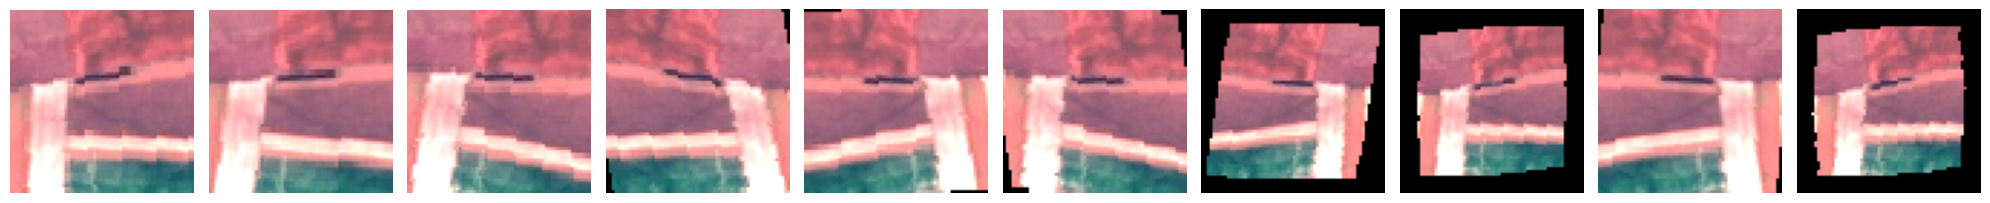

In [14]:
#visualize augmentation
def visualize_single_image_augmentations(image_label_pair, transform, repetitions=10):
    image, _ = image_label_pair  #unpack tuple: image,label

    fig, axes = plt.subplots(1, repetitions, figsize=(20, 3))

    for i in range(repetitions):
        img_tensor = transform(image)

        img_np = img_tensor.numpy()
        img_np = np.transpose(img_np, (1, 2, 0))

        img_np = img_np * 0.5 + 0.5 #rescale

        img_np = np.clip(img_np, 0, 1)

        axes[i].imshow(img_np)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

visualize_single_image_augmentations(raw_image_data[133], train_transform_augment)

In [15]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),


            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),


            nn.ReLU(),

            nn.MaxPool2d(2, 2),

            nn.Dropout(0.35),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),

            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),

            nn.ReLU(),

            nn.MaxPool2d(2, 2),

            nn.Dropout(0.35)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(64 * 16 * 16, 64),


            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.features(x)
        last_conv_output = x
        x = self.classifier(x)
        return x, last_conv_output

# Instantiate and summarize the model
cnn_model_aug = CNN().to(device)
summary(cnn_model_aug, input_size=(3, 64, 64))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 64, 64]             896
              ReLU-2           [-1, 32, 64, 64]               0
            Conv2d-3           [-1, 32, 64, 64]           9,248
              ReLU-4           [-1, 32, 64, 64]               0
         MaxPool2d-5           [-1, 32, 32, 32]               0
           Dropout-6           [-1, 32, 32, 32]               0
            Conv2d-7           [-1, 64, 32, 32]          18,496
              ReLU-8           [-1, 64, 32, 32]               0
            Conv2d-9           [-1, 64, 32, 32]          36,928
             ReLU-10           [-1, 64, 32, 32]               0
        MaxPool2d-11           [-1, 64, 16, 16]               0
          Dropout-12           [-1, 64, 16, 16]               0
          Flatten-13                [-1, 16384]               0
           Linear-14                   

In [16]:
def train_cnn_model_aug(epochs, model, optimizer, criterion, train_loader, val_loader, early_stopper):
    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()

            # Get only the logits from the model's output which is the first element of the tuple
            output, _ = model(data)  # Adjust here to unpack the tuple and ignore the second output
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_losses.append(train_loss / len(train_loader))

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                # Again, get only the logits when evaluating
                output, _ = model(data)
                loss = criterion(output, target)
                val_loss += loss.item()
        val_losses.append(val_loss / len(val_loader))
        print(f'Epoch: {epoch+1}, Training Loss: {train_loss / len(train_loader):.4f}, Validation Loss: {val_loss / len(val_loader):.4f}')

        # Early stopping call and pass the model for checkpointing
        early_stopper(val_loss / len(val_loader), model)
        if early_stopper.early_stop:
            print("Early stopping triggered.")
            break

    # Load the best model weights
    model.load_state_dict(torch.load('aug_checkpoint.pt'))
    return train_losses, val_losses

Epoch: 1, Training Loss: 1.8985, Validation Loss: 1.5086
Validation loss decreased (1.508613 --> 1.508613).  Saving model ...
Epoch: 2, Training Loss: 1.4175, Validation Loss: 1.1259
Validation loss decreased (1.508613 --> 1.125896).  Saving model ...
Epoch: 3, Training Loss: 1.1914, Validation Loss: 0.9734
Validation loss decreased (1.125896 --> 0.973396).  Saving model ...
Epoch: 4, Training Loss: 1.0540, Validation Loss: 0.8300
Validation loss decreased (0.973396 --> 0.830026).  Saving model ...
Epoch: 5, Training Loss: 0.9420, Validation Loss: 0.7608
Validation loss decreased (0.830026 --> 0.760813).  Saving model ...
Epoch: 6, Training Loss: 0.8604, Validation Loss: 0.7404
Validation loss decreased (0.760813 --> 0.740365).  Saving model ...
Epoch: 7, Training Loss: 0.8336, Validation Loss: 0.6765
Validation loss decreased (0.740365 --> 0.676470).  Saving model ...
Epoch: 8, Training Loss: 0.7480, Validation Loss: 0.5957
Validation loss decreased (0.676470 --> 0.595674).  Saving mo

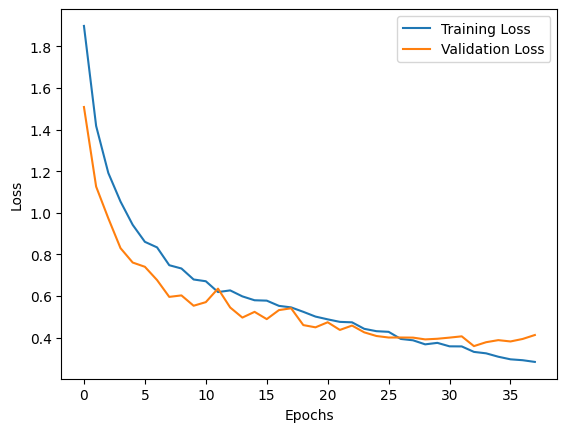


---------------CNN MODEL---------------

Accuracy: 0.8777475919980242
Classification Report:
               precision    recall  f1-score   support

           0     0.9029    0.8772    0.8899       456
           1     0.9412    0.9831    0.9617       472
           2     0.8753    0.7423    0.8033       454
           3     0.7798    0.7778    0.7788       378
           4     0.9484    0.9350    0.9417       354
           5     0.7889    0.8099    0.7992       263
           6     0.6996    0.8484    0.7668       376
           7     0.9405    0.9807    0.9602       467
           8     0.8739    0.7842    0.8266       380
           9     0.9821    0.9800    0.9810       449

    accuracy                         0.8777      4049
   macro avg     0.8733    0.8719    0.8709      4049
weighted avg     0.8809    0.8777    0.8777      4049

Confusion Matrix:
 [[400   3   3   8   0  15  20   0   3   4]
 [  0 464   4   0   0   3   0   0   0   1]
 [  4   6 337   7   3  10  67  11   8   1

In [17]:
# with augmentation
epochs = 50
patience = 5
lr = 0.001
reg = 0.0001


#CNN model, criterion, optimizer, and early stopping initialization
criterion = nn.CrossEntropyLoss() #multiclass classification
cnn_optimizer = optim.Adam(cnn_model_aug.parameters(), lr=lr, weight_decay=reg)  # Ensure this is for the cnn_model
early_stopper = EarlyStopping(patience=patience, path="aug_checkpoint.pt")

# Training the model
train_losses, val_losses = train_cnn_model_aug(epochs, cnn_model_aug, cnn_optimizer, criterion, train_loader, val_loader, early_stopper)

# Plotting the training and validation losses
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluate CNN model
print("\n---------------CNN MODEL---------------\n")
cnn_accuracy_aug = evaluate_model(val_loader, cnn_model_aug)

In [18]:
#test model on test set
# Evaluate CNN model
print("\n---------------CNN MODEL---------------\n")
cnn_accuracy = evaluate_model(test_loader, cnn_model)
print(cnn_accuracy)
# Evaluate CNN model
print("\n---------------CNN MODEL---------------\n")
cnn_accuracy_aug = evaluate_model(test_loader, cnn_model_aug)
print(cnn_accuracy_aug)


---------------CNN MODEL---------------

Accuracy: 0.89607504319921
Classification Report:
               precision    recall  f1-score   support

           0     0.9560    0.8826    0.9178       443
           1     0.9755    0.9755    0.9755       490
           2     0.8571    0.8326    0.8447       454
           3     0.8212    0.7737    0.7967       380
           4     0.9601    0.9108    0.9348       370
           5     0.8243    0.9053    0.8629       285
           6     0.8083    0.8517    0.8294       391
           7     0.9361    0.9930    0.9637       428
           8     0.7983    0.8120    0.8051       351
           9     0.9678    0.9826    0.9751       459

    accuracy                         0.8961      4051
   macro avg     0.8905    0.8920    0.8906      4051
weighted avg     0.8971    0.8961    0.8960      4051

Confusion Matrix:
 [[391   2   3   2   0   9  14   0  15   7]
 [  0 478   2   1   0   6   0   0   1   2]
 [  2   2 378   8   4   8  30  10  10   2]


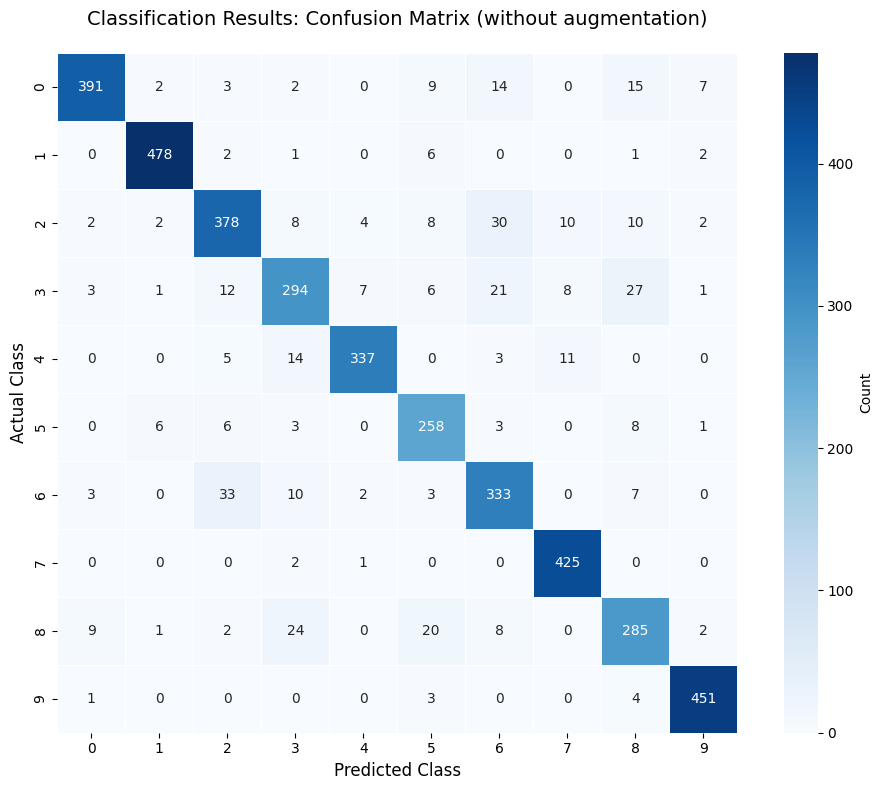

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix Data cnn without augmentation
confusion_matrix = np.array([
    [391,  2,  3,  2,  0,  9, 14,  0, 15,  7],
    [  0,478,  2,  1,  0,  6,  0,  0,  1,  2],
    [  2,  2,378,  8,  4,  8, 30, 10, 10,  2],
    [  3,  1, 12,294,  7,  6, 21,  8, 27,  1],
    [  0,  0,  5, 14,337,  0,  3, 11,  0,  0],
    [  0,  6,  6,  3,  0,258,  3,  0,  8,  1],
    [  3,  0, 33, 10,  2,  3,333,  0,  7,  0],
    [  0,  0,  0,  2,  1,  0,  0,425,  0,  0],
    [  9,  1,  2, 24,  0, 20,  8,  0,285,  2],
    [  1,  0,  0,  0,  0,  3,  0,  0,  4,451]
])

class_labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

# Create professional heatmap
plt.figure(figsize=(10, 8))
ax = sns.heatmap(confusion_matrix, 
                 annot=True,
                 fmt='d',
                 cmap='Blues',
                 xticklabels=class_labels,
                 yticklabels=class_labels,
                 cbar_kws={'label': 'Count'},
                 square=True,
                 linewidths=0.5)

plt.title('Classification Results: Confusion Matrix (without augmentation)', fontsize=14, pad=20)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('Actual Class', fontsize=12)
plt.tight_layout()
plt.show()


Bonus Tasks

Bonus Task 1: MLP vs CNN comparison (2 bonus points)

    • Train a Multi-Layer Perceptron (MLP) to classify the images and compare its performance with the CNN

In [19]:
def train_model(epochs, model, optimizer, criterion, train_loader, val_loader, early_stopper):
    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_losses.append(train_loss / len(train_loader))

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)
                val_loss += loss.item()
        val_losses.append(val_loss / len(val_loader))
        print(f'Epoch: {epoch+1}, Training Loss: {train_loss / len(train_loader):.4f}, Validation Loss: {val_loss / len(val_loader):.4f}')

        # Early stopping call and pass the model for checkpointing
        early_stopper(val_loss / len(val_loader), model)
        if early_stopper.early_stop:
            print("Early stopping triggered.")
            break

    # Load the best model weights
    model.load_state_dict(torch.load('mlp_checkpoint_jh.pt'))
    return train_losses, val_losses

In [20]:
import torch
import torch.nn as nn
from torchsummary import summary

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten() #only difference to the MLP we had before, first flatten the image, then network
        self.network = nn.Sequential(
            nn.Linear(3*64*64, 512),  # Adjusted input layer to match 28x28 input size
            nn.ReLU(),
            nn.Dropout(0.5),  # Adding dropout for regularization
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),  # Another dropout layer
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),  # Output layer for 10 classes, because we have 10 classes;
            #softmax already has a loss calculation, we dont want to compute it twice so no softmax at the end of mlp
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

# Instantiate the model and move it to the available device
model = MLP().to(device)
summary(model, input_size=(3, 64, 64)) # Updated to single channel, 28x28 input size

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                [-1, 12288]               0
            Linear-2                  [-1, 512]       6,291,968
              ReLU-3                  [-1, 512]               0
           Dropout-4                  [-1, 512]               0
            Linear-5                  [-1, 256]         131,328
              ReLU-6                  [-1, 256]               0
           Dropout-7                  [-1, 256]               0
            Linear-8                  [-1, 128]          32,896
              ReLU-9                  [-1, 128]               0
           Linear-10                   [-1, 10]           1,290
Total params: 6,457,482
Trainable params: 6,457,482
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.05
Forward/backward pass size (MB): 0.11
Params size (MB): 24.63
Estima

Epoch: 1, Training Loss: 2.0453, Validation Loss: 1.8598
Validation loss decreased (1.859817 --> 1.859817).  Saving model ...
Epoch: 2, Training Loss: 1.8550, Validation Loss: 1.7418
Validation loss decreased (1.859817 --> 1.741799).  Saving model ...
Epoch: 3, Training Loss: 1.7389, Validation Loss: 1.6028
Validation loss decreased (1.741799 --> 1.602828).  Saving model ...
Epoch: 4, Training Loss: 1.6180, Validation Loss: 1.5026
Validation loss decreased (1.602828 --> 1.502574).  Saving model ...
Epoch: 5, Training Loss: 1.5253, Validation Loss: 1.4456
Validation loss decreased (1.502574 --> 1.445593).  Saving model ...
Epoch: 6, Training Loss: 1.4681, Validation Loss: 1.3845
Validation loss decreased (1.445593 --> 1.384506).  Saving model ...
Epoch: 7, Training Loss: 1.4278, Validation Loss: 1.3521
Validation loss decreased (1.384506 --> 1.352108).  Saving model ...
Epoch: 8, Training Loss: 1.3879, Validation Loss: 1.3247
Validation loss decreased (1.352108 --> 1.324672).  Saving mo

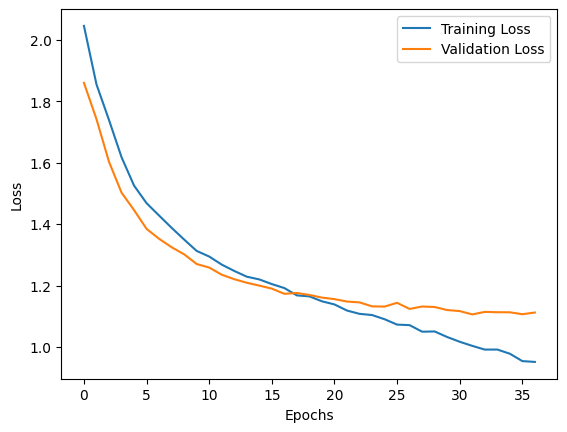

In [21]:
batch_size = 512
epochs = 50
patience = 5
lr = 0.0001
reg = 0.0001

# MLP model, criterion, optimizer, and early stopping initialization
model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=reg)  # L2 regularization
early_stopper = EarlyStopping(patience=patience, path="mlp_checkpoint_jh.pt")

# Training the model
train_losses, val_losses = train_model(epochs, model, optimizer, criterion, train_loader_mlp, val_loader_mlp, early_stopper)

# Plotting the training and validation losses
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [22]:
# Evaluate MLP model
print("\n---------------MLP MODEL---------------\n")
mlp_accuracy = evaluate_model(val_loader_mlp, model)


---------------MLP MODEL---------------

Accuracy: 0.609780192640158
Classification Report:
               precision    recall  f1-score   support

           0     0.5720    0.6360    0.6023       456
           1     0.7903    0.8623    0.8247       472
           2     0.5350    0.4207    0.4710       454
           3     0.4545    0.3175    0.3738       378
           4     0.6948    0.8362    0.7590       354
           5     0.6497    0.7262    0.6858       263
           6     0.5274    0.2048    0.2950       376
           7     0.5500    0.6831    0.6094       467
           8     0.4373    0.6053    0.5077       380
           9     0.8018    0.7751    0.7882       449

    accuracy                         0.6098      4049
   macro avg     0.6013    0.6067    0.5917      4049
weighted avg     0.6043    0.6098    0.5953      4049

Confusion Matrix:
 [[290   1  32  21  12  15  28  17  34   6]
 [  0 407   1   0   0  18   0   3   0  43]
 [ 26  17 191  31  23   9  24  83  38  12]

In [23]:
#comparison
# Evaluate MLP model
print("\n---------------MLP MODEL---------------\n")
mlp_accuracy = evaluate_model(test_loader_mlp, model)


---------------MLP MODEL---------------

Accuracy: 0.6028141199703777
Classification Report:
               precision    recall  f1-score   support

           0     0.5734    0.6524    0.6103       443
           1     0.7981    0.8469    0.8218       490
           2     0.5233    0.4207    0.4664       454
           3     0.4481    0.2842    0.3478       380
           4     0.7107    0.8432    0.7713       370
           5     0.6535    0.7544    0.7003       285
           6     0.5665    0.2506    0.3475       391
           7     0.5076    0.6262    0.5607       428
           8     0.4128    0.6268    0.4977       351
           9     0.7780    0.7102    0.7426       459

    accuracy                         0.6028      4051
   macro avg     0.5972    0.6016    0.5867      4051
weighted avg     0.6030    0.6028    0.5908      4051

Confusion Matrix:
 [[289   2  30  17  15   7  24   6  48   5]
 [  0 415   0   0   0  19   0   6   2  48]
 [ 31  15 191  36  19   9  20  89  36   8

In [24]:
# Evaluate CNN model
print("\n---------------CNN MODEL---------------\n")
cnn_accuracy = evaluate_model(test_loader, cnn_model)


---------------CNN MODEL---------------

Accuracy: 0.89607504319921
Classification Report:
               precision    recall  f1-score   support

           0     0.9560    0.8826    0.9178       443
           1     0.9755    0.9755    0.9755       490
           2     0.8571    0.8326    0.8447       454
           3     0.8212    0.7737    0.7967       380
           4     0.9601    0.9108    0.9348       370
           5     0.8243    0.9053    0.8629       285
           6     0.8083    0.8517    0.8294       391
           7     0.9361    0.9930    0.9637       428
           8     0.7983    0.8120    0.8051       351
           9     0.9678    0.9826    0.9751       459

    accuracy                         0.8961      4051
   macro avg     0.8905    0.8920    0.8906      4051
weighted avg     0.8971    0.8961    0.8960      4051

Confusion Matrix:
 [[391   2   3   2   0   9  14   0  15   7]
 [  0 478   2   1   0   6   0   0   1   2]
 [  2   2 378   8   4   8  30  10  10   2]


In [25]:
# Evaluate CNN model
print("\n---------------CNN MODEL---------------\n")
cnn_accuracy_aug = evaluate_model(test_loader, cnn_model_aug)


---------------CNN MODEL---------------

Accuracy: 0.8896568748457171
Classification Report:
               precision    recall  f1-score   support

           0     0.9157    0.9074    0.9116       443
           1     0.9599    0.9776    0.9687       490
           2     0.8973    0.7313    0.8058       454
           3     0.7898    0.7711    0.7803       380
           4     0.9464    0.9541    0.9502       370
           5     0.8400    0.8842    0.8615       285
           6     0.7250    0.8900    0.7991       391
           7     0.9507    0.9907    0.9703       428
           8     0.8622    0.7664    0.8115       351
           9     0.9805    0.9847    0.9826       459

    accuracy                         0.8897      4051
   macro avg     0.8867    0.8857    0.8841      4051
weighted avg     0.8926    0.8897    0.8890      4051

Confusion Matrix:
 [[402   3   4   7   0   5  10   0   8   4]
 [  0 479   5   1   0   4   0   0   1   0]
 [  6   4 332   9   6   8  73   8   6   2

Bonus Task 2: Feature visualization and interpretation (2 bonus points)

    • Visualize the activations of the last convolutional layer and discuss which features the model has learned
    
    • Show some relevant examples in the report and interpret what patterns the CNN is detecting for different land use categories
    
    • Discuss how these visualizations help understand the model’s classification decisions

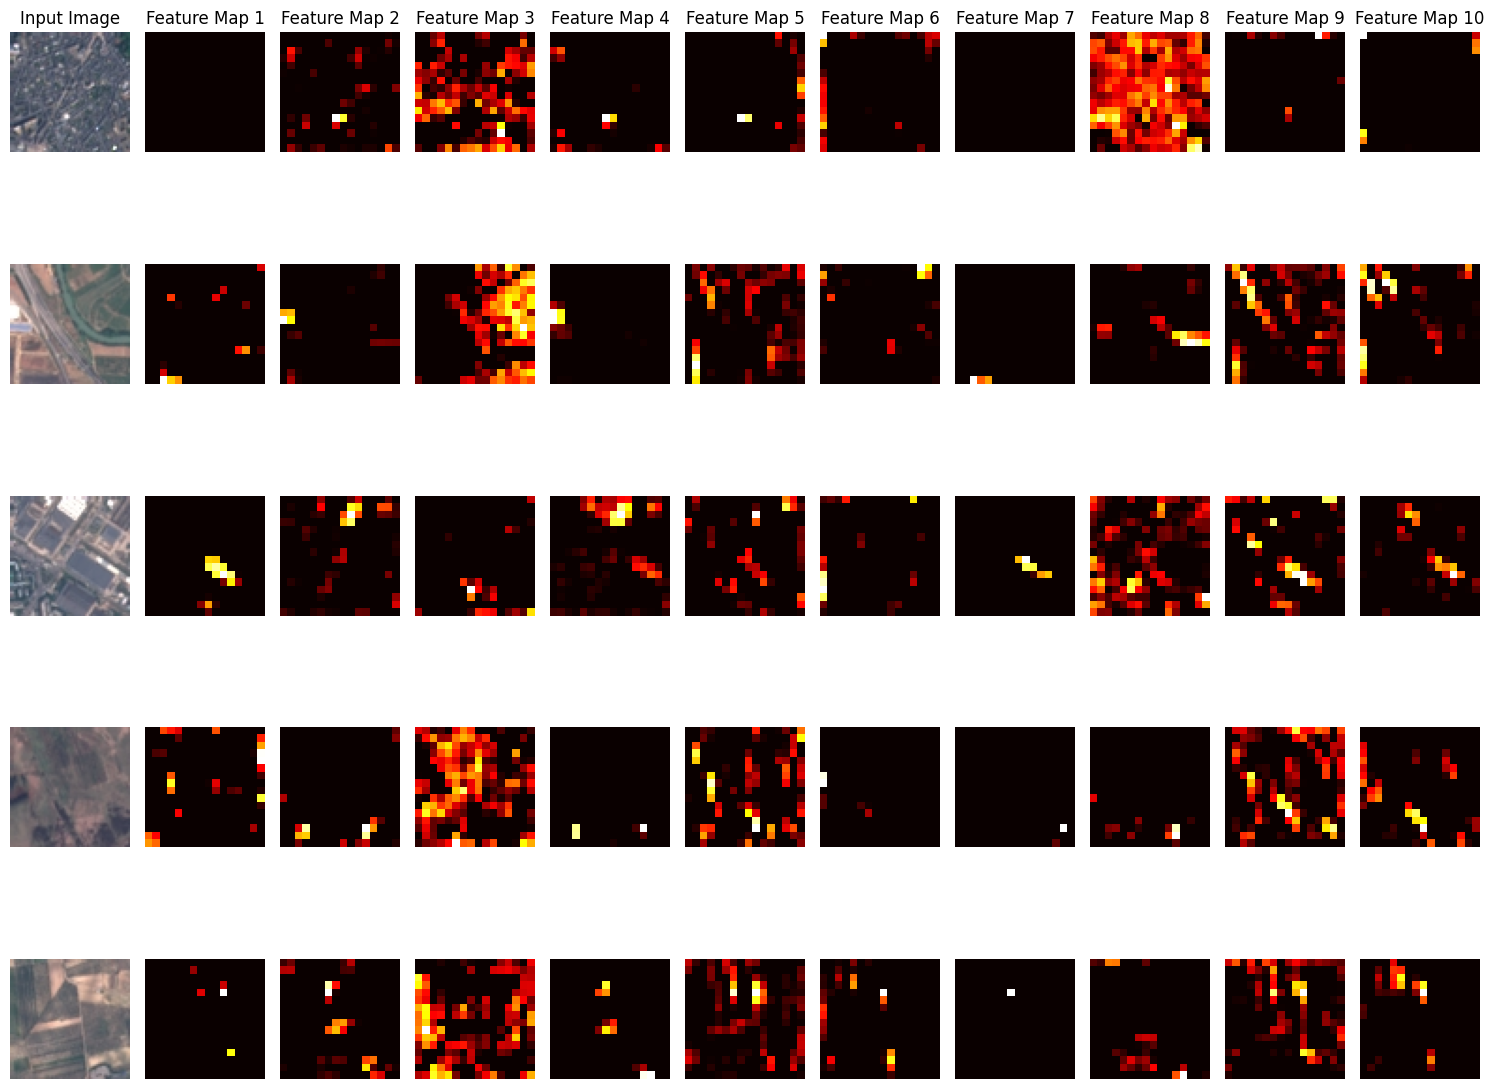

In [26]:
import matplotlib.pyplot as plt
import torch
import torchvision

def visualize_features_and_inputs(model, data_loader, num_images=5, num_maps=5):
    model.eval()  # Ensure the model is in eval mode
    fig, axes = plt.subplots(num_images, num_maps + 1, figsize=(15, 2.5 * num_images))  # Rows, Columns

    for idx in range(num_images):
        # Get the next batch of images
        images, _ = next(iter(data_loader))  # Get a batch of images
        images = images.to(device)

        # Get the final output and feature maps from the model
        _, feature_maps = model(images)
        feature_maps = feature_maps.cpu().data

        # Display the input image # Move to CPU first, then make grid
        input_img = images[idx].cpu()
        mean = torch.tensor([0.485, 0.456, 0.406])
        std = torch.tensor([0.229, 0.224, 0.225])
        input_img = input_img * std[:, None, None] + mean[:, None, None]
        input_img = torch.clamp(input_img, 0, 1)
        axes[idx, 0].imshow(input_img.permute(1, 2, 0))
        axes[idx, 0].set_title('Input Image' if idx == 0 else '')  # Title only on the first row
        axes[idx, 0].axis('off')

        # Display all feature maps on the same row
        for i in range(num_maps):
            if i < feature_maps.size(1):  # Check if the feature map index exists
                fmap = feature_maps[idx, i]  # 0 is the first image of the batch, i is the feature map index
                axes[idx, i + 1].imshow(fmap, cmap='hot')
                axes[idx, i + 1].set_title(f'Feature Map {i+1}' if idx == 0 else '')  # Title only on the first row
                axes[idx, i + 1].axis('off')
            else:
                # Clear any unused axes if there are fewer feature maps than num_maps
                axes[idx, i + 1].axis('off')

    plt.tight_layout()
    plt.show()

# Call the visualization function specifying the number of images and feature maps
visualize_features_and_inputs(cnn_model, test_loader, num_images=5, num_maps=10)